<a href="https://colab.research.google.com/github/mkg6573/social_media_impact_on_life_ml_/blob/main/Supervised%20Learning%20Algorithms/NaiveBayes_GridSearchCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# IMPORTING LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Pipeline
from sklearn.pipeline import Pipeline

# GridSearchCV
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)

# Ignore Warnings
import warnings

warnings.filterwarnings('ignore')

###LOADING DATASET

In [2]:
df = pd.read_csv(
    "/content/Cleaned_Social_media_impact_on_life_Clean_Dataset.csv"
)

# Display Dataset
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [3]:
print("Shape of Dataset : ")

print(df.shape)

Shape of Dataset : 
(1705, 9)


In [4]:
print("\nColumns in Dataset : ")

print(df.columns)



Columns in Dataset : 
Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')


In [5]:
print(df.columns)

print("\nMissing Values : ")

Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')

Missing Values : 


In [6]:
print(df.isnull().sum())

Age                             0
Gender                          0
Academic_Level                  0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64


###LABEL ENCODING

In [7]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(
            df[col]
        )

# Display Encoded Data
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,1,2,4.0,0,0,6.7,6.8,1
1,23,0,2,1.6,4,0,8.6,7.6,2
2,22,1,0,4.6,1,0,6.7,7.0,1
3,18,1,2,7.0,5,1,5.4,5.3,0
4,24,0,1,7.5,0,1,5.0,4.4,0


###FEATURE SELECTION

In [8]:
X = df.drop(

    ["Overall_Impact",
     "Mental_Health_Score"],

    axis=1
)

y = df["Overall_Impact"]

# Encode Target Variable
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("Features Shape : ")

print(X.shape)

print("\nTarget Shape : ")

print(y.shape)

print("\nFeature Columns : ")

print(X.columns)

Features Shape : 
(1705, 7)

Target Shape : 
(1705,)

Feature Columns : 
Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night'],
      dtype='object')


###TRAIN TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

print("Training Data Shape : ")

print(X_train.shape)

print("\nTesting Data Shape : ")

print(X_test.shape)

Training Data Shape : 
(1364, 7)

Testing Data Shape : 
(341, 7)


###BASELINE NAIVE BAYES MODEL

In [10]:
nb_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', GaussianNB())
])

# Train Model
nb_pipeline.fit(

    X_train,

    y_train
)

# Prediction
baseline_pred = nb_pipeline.predict(

    X_test
)

# Accuracy
baseline_acc = accuracy_score(

    y_test,

    baseline_pred
)

print(
    "Baseline Accuracy : ",

    baseline_acc
)

Baseline Accuracy :  0.8357771260997068


###CONFUSION MATRIX

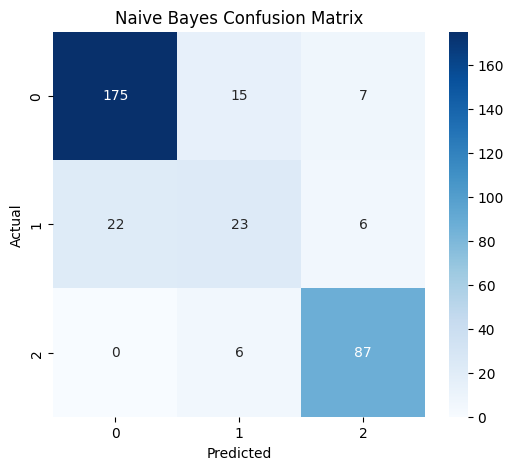

In [11]:
cm = confusion_matrix(

    y_test,

    baseline_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [12]:
print(
    classification_report(

        y_test,

        baseline_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       197
           1       0.52      0.45      0.48        51
           2       0.87      0.94      0.90        93

    accuracy                           0.84       341
   macro avg       0.76      0.76      0.76       341
weighted avg       0.83      0.84      0.83       341



##GRIDSEARCHCV HYPERPARAMETER TUNING

In [13]:
# Create Pipeline
nb_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', GaussianNB())
])

# Parameter Grid
param_grid = {

    'model__var_smoothing': [

        1e-9,

        1e-8,

        1e-7,

        1e-6,

        1e-5
    ]
}

# GridSearchCV
grid_nb = GridSearchCV(

    estimator=nb_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    verbose=1
)

# Train Model
grid_nb.fit(

    X_train,

    y_train
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', GaussianNB())]),
             param_grid={'model__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06,
                                                  1e-05]},
             scoring='accuracy', verbose=1)

###BEST PARAMETERS

In [14]:
print("Best Parameters : ")

print(
    grid_nb.best_params_
)

print("\nBest Accuracy : ")

print(
    grid_nb.best_score_
)

Best Parameters : 
{'model__var_smoothing': 1e-09}

Best Accuracy : 
0.8357385261797028


RESULTS TABLE

In [15]:
nb_results = pd.DataFrame(

    grid_nb.cv_results_
)

nb_results[[

    'param_model__var_smoothing',

    'mean_test_score'
]]

,param_model__var_smoothing,mean_test_score
0,1.000000e-09,0.835739
1,1.000000e-08,0.835739
2,1.000000e-07,0.835739
3,1.000000e-06,0.835739
4,1.000000e-05,0.835739


###VISUALIZATION

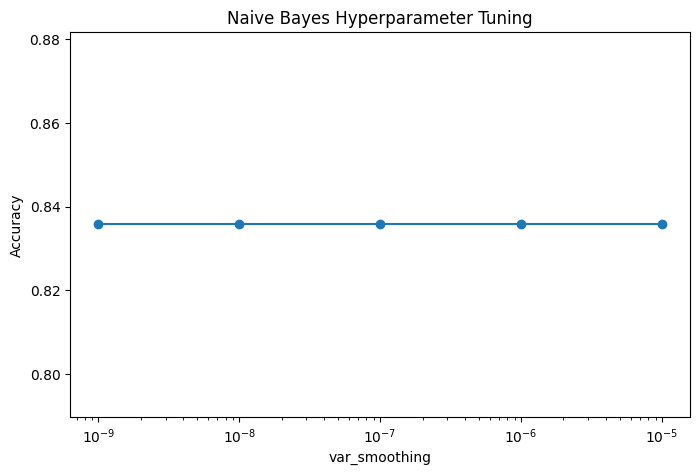

In [16]:
plt.figure(figsize=(8,5))

plt.plot(

    nb_results[
        'param_model__var_smoothing'
    ],

    nb_results[
        'mean_test_score'
    ],

    marker='o'
)

plt.xscale('log')

plt.title(
    "Naive Bayes Hyperparameter Tuning"
)

plt.xlabel(
    "var_smoothing"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

###BEST MODEL PREDICTION

In [17]:
best_nb_model = grid_nb.best_estimator_

best_pred = best_nb_model.predict(

    X_test
)

best_acc = accuracy_score(

    y_test,

    best_pred
)

print(
    "Tuned Model Accuracy : ",

    best_acc
)

Tuned Model Accuracy :  0.8357771260997068


###FINAL COMPARISON

In [18]:
comparison_df = pd.DataFrame({

    'Model': [

        'Baseline Naive Bayes',

        'Tuned Naive Bayes'
    ],

    'Accuracy': [

        baseline_acc,

        best_acc
    ]
})

comparison_df

,Model,Accuracy
0,Baseline Naive Bayes,0.835777
1,Tuned Naive Bayes,0.835777


###COMPARISON GRAPH

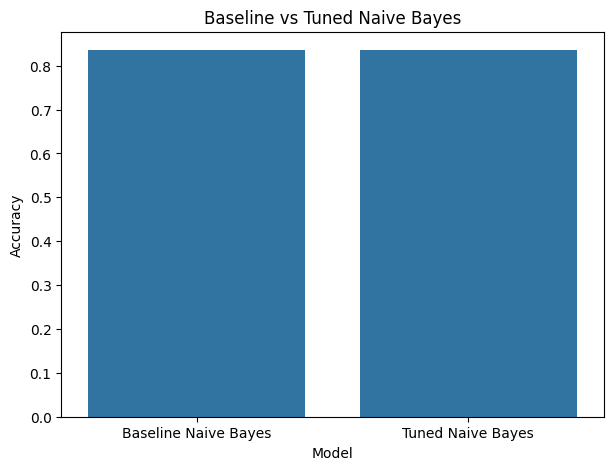

In [19]:
plt.figure(figsize=(7,5))

sns.barplot(

    x='Model',

    y='Accuracy',

    data=comparison_df
)

plt.title(
    "Baseline vs Tuned Naive Bayes"
)

plt.show()

#Analysis:

GridSearchCV was used to perform hyperparameter tuning on the Gaussian Naive Bayes model.

 GridSearchCV automatically tests different hyperparameter values using cross-validation and selects the best-performing configuration.
    
  In Gaussian Naive Bayes, the
  var_smoothing parameter is used
  to improve numerical stability by
  adding a small value to the variance.
    
  Different var_smoothing values were
  tested to observe their effect on
  model accuracy.
  
  However, the baseline and tuned
  Naive Bayes models both achieved
  the same accuracy of 83.57%.
  
  This indicates that the dataset is
  already well-behaved and stable,
  and changing the var_smoothing
  parameter did not significantly
  influence the prediction performance.
  
  Therefore, hyperparameter tuning
  produced minimal impact on the
  Gaussian Naive Bayes model for
  this dataset.
